# Scientific colormaps in cleopatra

Matplotlib's built-in colormaps are fine for quick looks, but scientific figures want **perceptually uniform,
colour-vision-deficiency-safe** colormaps such as the [cmocean](https://matplotlib.org/cmocean/),
[cmasher](https://cmasher.readthedocs.io/), [Crameri](https://www.fabiocrameri.ch/colourmaps/) and ColorBrewer
collections. cleopatra reaches all of them through one small optional dependency and a single resolver,
[`cleopatra.styling.colors.resolve_colormap`](../../../src/cleopatra/colors.py).

By the end of this notebook you will be able to:

- pass a **namespaced** colormap name (e.g. `"cmocean:thermal"`) to any cleopatra glyph;
- reverse any colormap with the `_r` suffix;
- resolve a colormap object directly and understand the `[science-colors]` extra.

The feature ships as an optional extra so it never becomes a hard dependency:

```bash
pip install "cleopatra[science-colors]"
```

## Setup

We load a real field to colour: 45 daily maps of European 2 m air temperature (°C) plus a North-Atlantic elevation grid. Paths are relative to this notebook's folder.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from cleopatra.glyphs.gridded.array_glyph import ArrayGlyph
from cleopatra.styling.colors import resolve_colormap

DATA = Path("../../../examples/data")
t2m = np.load(DATA / "europe_t2m.npz")
temperature = t2m["celsius"][0]          # first day, degrees Celsius
temp_extent = list(t2m["extent"])        # [west, east, south, north]
temperature.shape, temp_extent

((111, 164),
 [np.float64(-12.037),
  np.float64(32.006),
  np.float64(34.07),
  np.float64(63.73)])

## Quickstart: a perceptual temperature map

The only change from an ordinary call is the colormap name: `"cmocean:thermal"` (collection `cmocean`, map `thermal`). cleopatra resolves it through the `cmap` package automatically — nothing else about the call changes.

One layout note used throughout: cleopatra draws maps with **equal aspect** in a fixed figure and does not `tight_layout` (that is incompatible with its manually-placed colorbar). So we pass a `figsize` shaped like the region — otherwise a wide field collapses into a thin strip and the title crowds the colorbar.

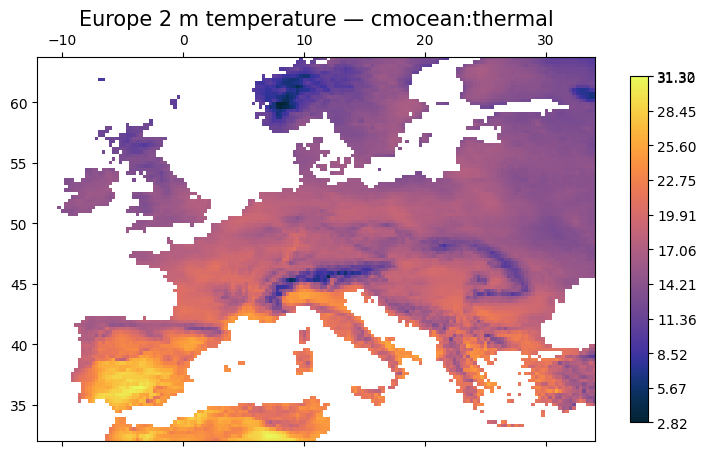

In [2]:
glyph = ArrayGlyph(temperature, extent=temp_extent, cmap="cmocean:thermal", figsize=(9, 6))
fig, ax = glyph.plot(title="Europe 2 m temperature — cmocean:thermal")

`cmocean:thermal` runs cool-blue → warm-yellow with even perceived contrast, so equal temperature steps look equally different everywhere — unlike a rainbow map, which invents false edges.

## The namespace syntax

A namespaced name is `collection:name`. The `cmap` aggregator bundles many collections; a few useful ones:

| name | collection | good for |
|------|-----------|----------|
| `cmocean:thermal` | cmocean | temperature |
| `cmocean:deep` / `cmocean:topo` | cmocean | depth / land+sea elevation |
| `cmasher:ember` | cmasher | heat / intensity |
| `crameri:batlow` | Crameri | general perceptual default |
| `colorbrewer:RdYlBu_11` | ColorBrewer | diverging anomalies |

**Plain** matplotlib names (`"viridis"`, `"coolwarm_r"`) keep working unchanged — only names containing a colon
are routed to the `cmap` package. Below we resolve three of them and compare on the same field.

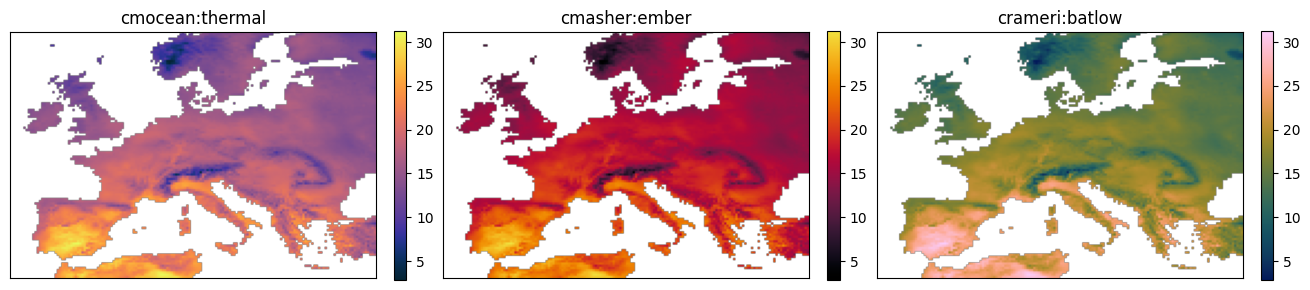

In [3]:
names = ["cmocean:thermal", "cmasher:ember", "crameri:batlow"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), constrained_layout=True)
for ax, name in zip(axes, names):
    im = ax.imshow(temperature, extent=temp_extent, origin="upper", cmap=resolve_colormap(name))
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.8)

Same data, three perceptual palettes: each maps the −2…39 °C range without banding. Picking one is now a matter of taste and domain convention, not of fighting matplotlib's defaults.

## Reversing a colormap

Append `_r` to reverse any colormap — plain or namespaced.

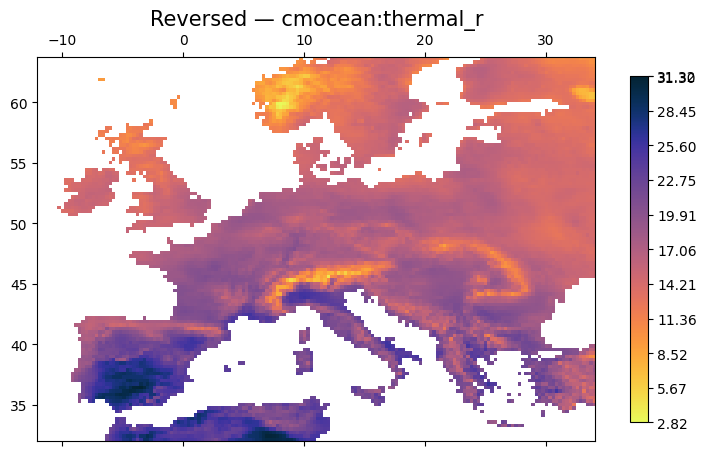

In [4]:
glyph = ArrayGlyph(temperature, extent=temp_extent, cmap="cmocean:thermal_r", figsize=(9, 6))
fig, ax = glyph.plot(title="Reversed — cmocean:thermal_r")

## Elevation with a land+sea colormap

`cmocean:topo` is a **hypsometric** colormap: one colour family for the ocean (blues) and another for land (greens/browns), meeting at a hinge. For that hinge to land on **sea level**, centre the colour scale at 0 with `color_scale="midpoint", midpoint=0` — otherwise the ocean/land split falls at the middle of the *data* range (here ≈ −1100 m), not at the coastline.

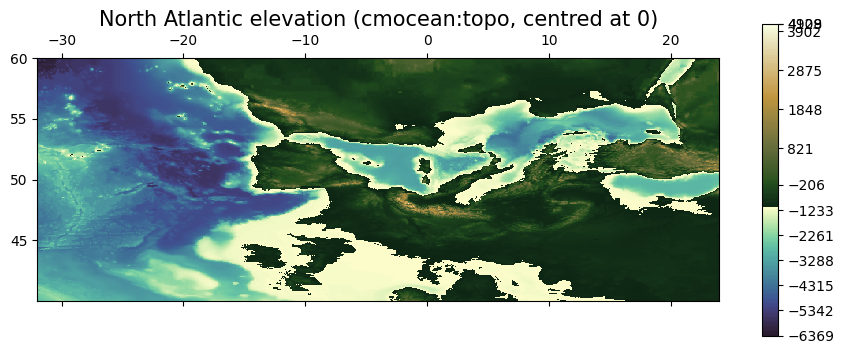

In [5]:
etopo = np.load(DATA / "etopo5_natlantic.npz")
elevation = etopo["elevation"]
glyph = ArrayGlyph(elevation, extent=list(etopo["extent"]), cmap="cmocean:topo",
                   color_scale="midpoint", midpoint=0, figsize=(11, 5.4))
fig, ax = glyph.plot(title="North Atlantic elevation (cmocean:topo, centred at 0)")

This is a **single** colorbar. Because `topo` carries two colour families it *reads* as two bands stacked: ocean blues below sea level, land greens/browns above, with the pale hinge now sitting exactly at 0. Deep water is dark blue, shelves are pale, and higher ground trends brown.

## Resolving a colormap directly

`resolve_colormap` is the single seam every glyph uses. It returns a normal matplotlib `Colormap`, so you can use it anywhere. Plain names never touch the optional package, and an unknown namespaced name fails with a message that names the offending value.

In [6]:
print("plain   :", resolve_colormap("viridis").name)
print("namespaced:", type(resolve_colormap("crameri:oleron")).__name__)
try:
    resolve_colormap("cmocean:not_a_real_map")
except ValueError as exc:
    print("bad name ->", exc)

plain   : viridis
namespaced: LinearSegmentedColormap
bad name -> cmap='cmocean:not_a_real_map' is not a known namespaced colormap: Colormap 'cmocean:not_a_real_map' not found.


## Takeaway

- Any cleopatra glyph accepts a **namespaced** colormap (`cmocean:thermal`, `crameri:batlow`, …) once the
  `cleopatra[science-colors]` extra is installed; plain matplotlib names are unchanged.
- `_r` reverses either kind.
- [`resolve_colormap`](../../../src/cleopatra/colors.py) is the resolver behind the scenes and is usable on its own.

Next: the [projection notebook](../projection/projection_examples.ipynb) puts these fields on a globe.